C:\Users\rasik\AppData\Local\Temp\ipykernel_12784\2665747000.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_df[col] = merged_df[col].replace({'Y': 1, 'N': 0})
C:\Users\rasik\AppData\Local\Temp\ipykernel_12784\2665747000.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weighted Percentage', y='Name', data=top_5_students, palette='viridis')


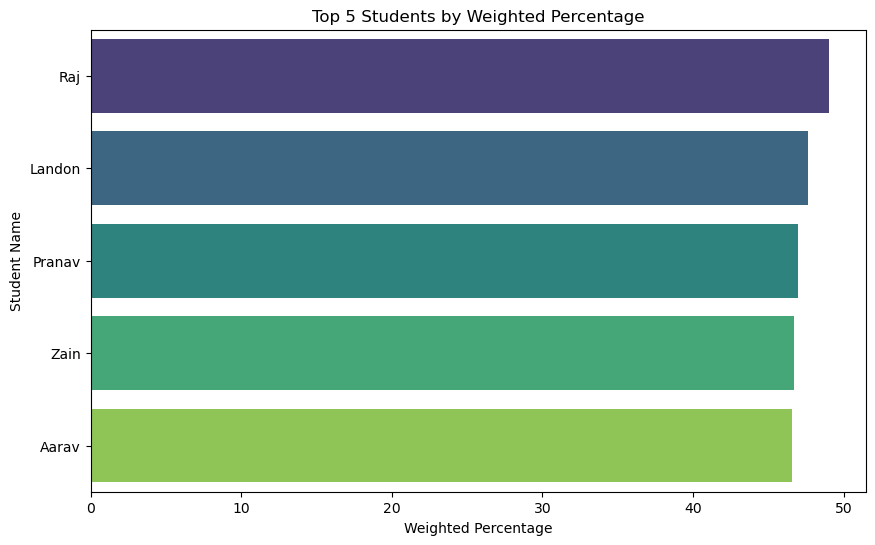

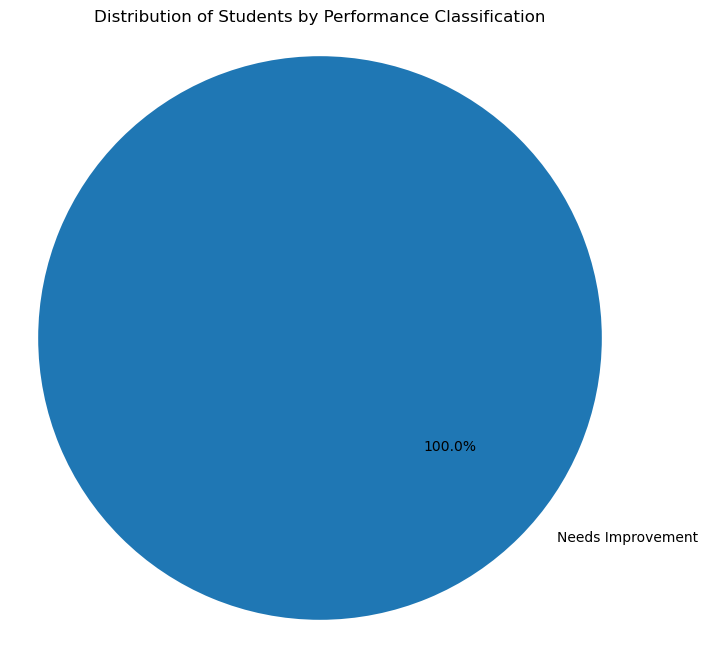

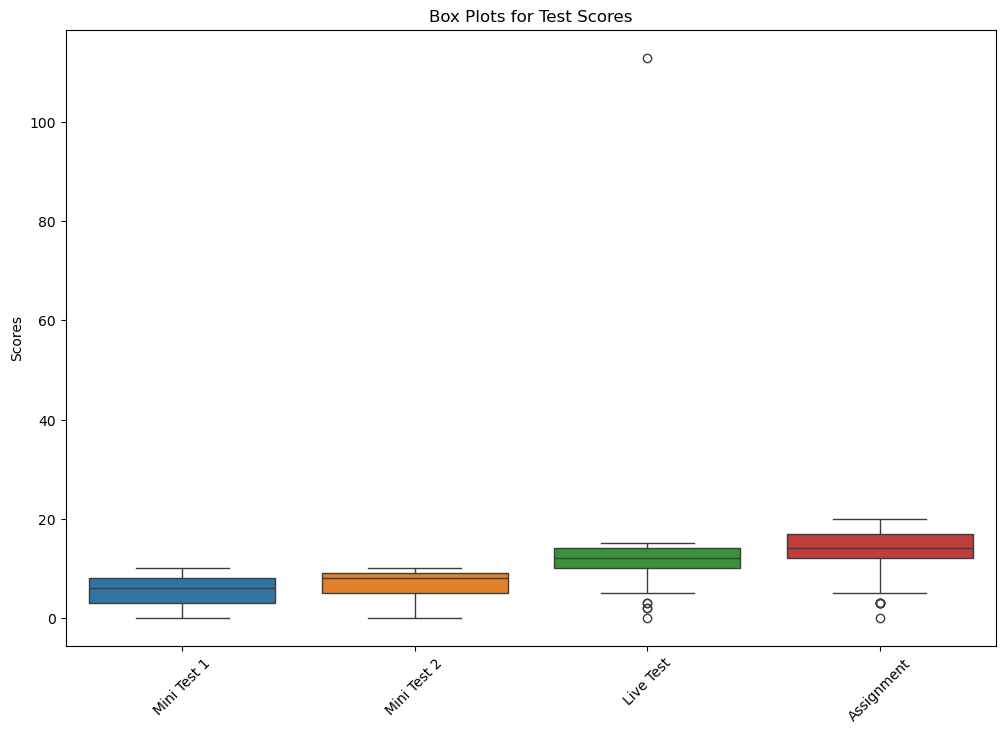

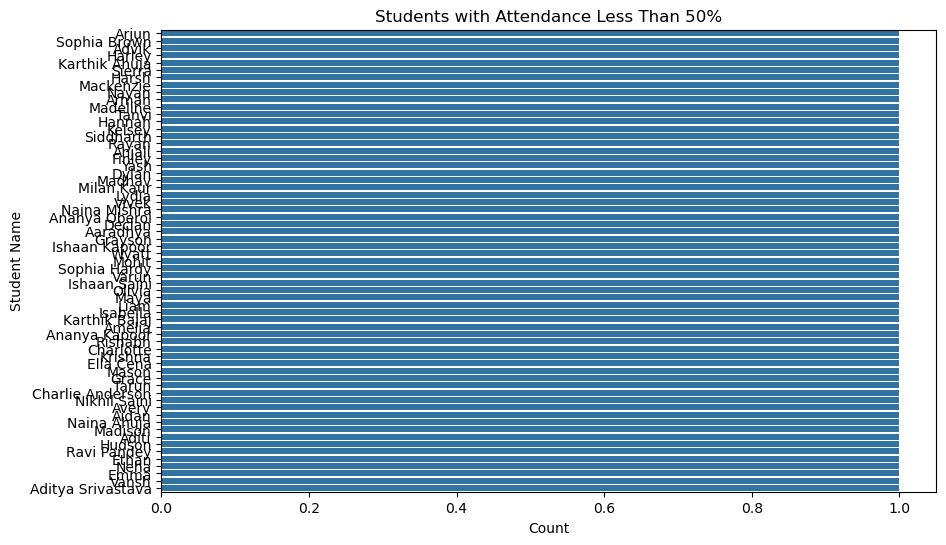

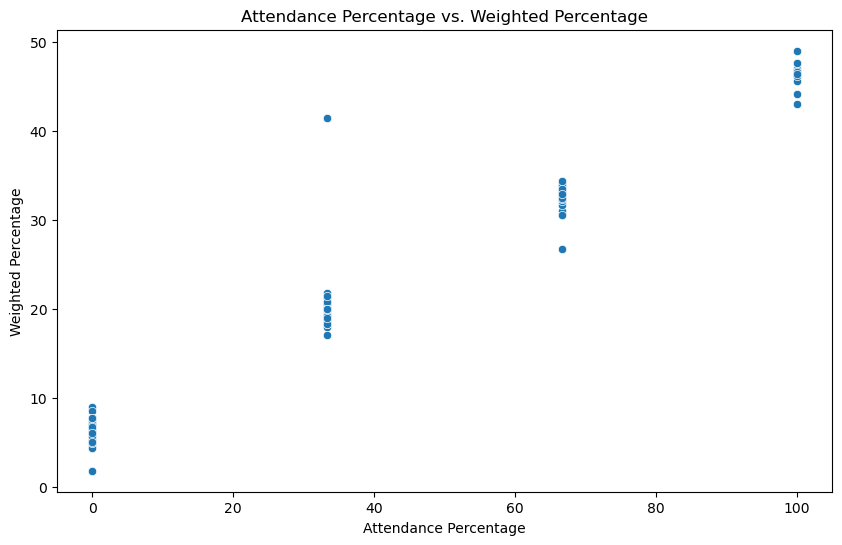

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

marks_df = pd.read_excel("Student_Performance_Analysis.xlsx", sheet_name='Marks')  
attendance_df = pd.read_excel("Student_Performance_Analysis.xlsx", sheet_name='Attendance')  

merged_df = pd.merge(marks_df, attendance_df, on='Name')
attendance_columns = ['Attendance Day 1', 'Attendance Day 2', 'Attendance Day 3'] 
for col in attendance_columns:
    merged_df[col] = merged_df[col].replace({'Y': 1, 'N': 0})

merged_df.fillna(0, inplace=True)
merged_df['Name'] = merged_df['Name'].str.title()

marks_columns = ['Mini Test 1', 'Mini Test 2', 'Live Test', 'Assignment']
for col in attendance_columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')
for col in marks_columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

merged_df['Total Marks'] = merged_df[marks_columns].sum(axis=1)
merged_df['Percentage Marks'] = (merged_df['Total Marks'] / (len(marks_columns) * 100)) * 100

merged_df['Attendance Percentage'] = merged_df[attendance_columns].mean(axis=1) * 100
weights = {
    'Attendance': 0.4,
    'Mini Test 1': 0.1,
    'Mini Test 2': 0.1,
    'Live Test': 0.2,
    'Assignment': 0.2
}

merged_df['Weighted Percentage'] = (
    merged_df['Attendance Percentage'] * weights['Attendance'] +
    merged_df['Mini Test 1'] * weights['Mini Test 1'] +
    merged_df['Mini Test 2'] * weights['Mini Test 2'] +
    merged_df['Live Test'] * weights['Live Test'] +
    merged_df['Assignment'] * weights['Assignment']
)

def classify_performance(weighted_percentage):
    if weighted_percentage >= 85:
        return 'Excellent'
    elif weighted_percentage >= 71:
        return 'Good'
    elif weighted_percentage >= 50:
        return 'Average'
    else:
        return 'Needs Improvement'

merged_df['Performance Classification'] = merged_df['Weighted Percentage'].apply(classify_performance)

low_attendance_good_performance = merged_df[(merged_df['Attendance Percentage'] < 75) & (merged_df['Weighted Percentage'] > 50)]
top_three_students = merged_df.nlargest(3, 'Percentage Marks')

top_5_students = merged_df.nlargest(5, 'Weighted Percentage')
plt.figure(figsize=(10, 6))
sns.barplot(x='Weighted Percentage', y='Name', data=top_5_students, palette='viridis')
plt.title('Top 5 Students by Weighted Percentage')
plt.xlabel('Weighted Percentage')
plt.ylabel('Student Name')
plt.show()

performance_counts = merged_df['Performance Classification'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(performance_counts, labels=performance_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Students by Performance Classification')
plt.axis('equal')
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(data=merged_df[marks_columns])
plt.title('Box Plots for Test Scores')
plt.ylabel('Scores')
plt.xticks(rotation=45)
plt.show()

low_attendance_students = merged_df[merged_df['Attendance Percentage'] < 50]
plt.figure(figsize=(10, 6))
sns .countplot(y='Name', data=low_attendance_students, order=low_attendance_students['Name'].value_counts().index)
plt.title('Students with Attendance Less Than 50%')
plt.xlabel('Count')
plt.ylabel('Student Name')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Attendance Percentage', y='Weighted Percentage', data=merged_df)
plt.title('Attendance Percentage vs. Weighted Percentage')
plt.xlabel('Attendance Percentage')
plt.ylabel('Weighted Percentage')
plt.show()


C:\Users\rasik\AppData\Local\Temp\ipykernel_12784\917128305.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_df[col] = merged_df[col].replace({'Y': 1, 'N': 0})
C:\Users\rasik\AppData\Local\Temp\ipykernel_12784\917128305.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weighted Percentage', y='Name', data=top_5_students, palette='Blues_d')
C:\Users\rasik\AppData\Local\Temp\ipykernel_12784\917128305.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.cou

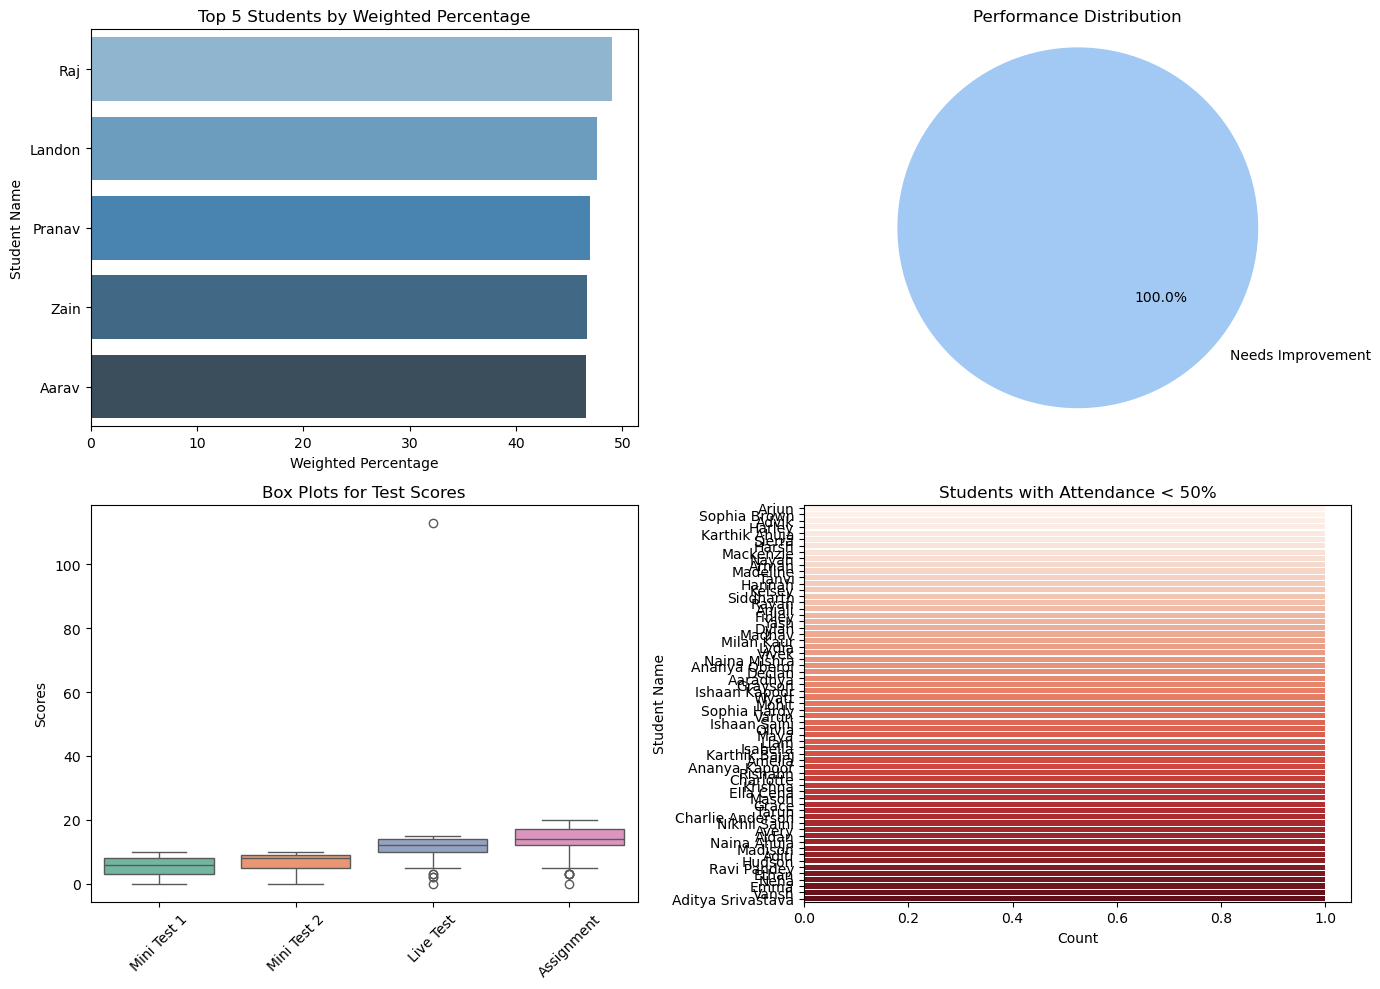

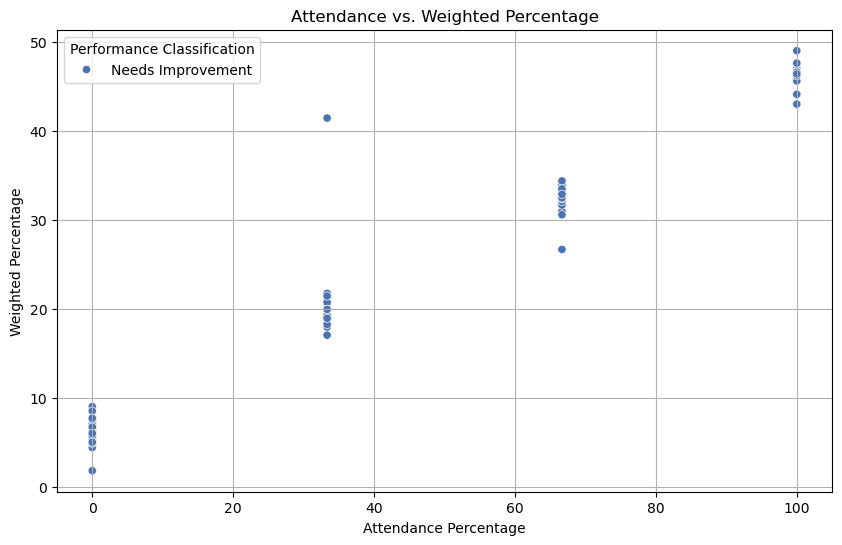

In [22]:
"""imporeted libraries already in above code"""

marks_df = pd.read_excel("Student_Performance_Analysis.xlsx", sheet_name='Marks') 
attendance_df = pd.read_excel("Student_Performance_Analysis.xlsx", sheet_name='Attendance') 
merged_df = pd.merge(marks_df, attendance_df, on='Name')

attendance_columns = ['Attendance Day 1', 'Attendance Day 2', 'Attendance Day 3']
for col in attendance_columns:
    merged_df[col] = merged_df[col].replace({'Y': 1, 'N': 0})

for col in attendance_columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')
merged_df.fillna(0, inplace=True)

merged_df['Name'] = merged_df['Name'].str.title()
marks_columns = ['Mini Test 1', 'Mini Test 2', 'Live Test', 'Assignment']
for col in marks_columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

merged_df['Total Marks'] = merged_df[marks_columns].sum(axis=1)
merged_df['Percentage Marks'] = (merged_df['Total Marks'] / (len(marks_columns) * 100)) * 100
merged_df['Attendance Percentage'] = merged_df[attendance_columns].mean(axis=1) * 100

weights = {
    'Attendance': 0.4,
    'Mini Test 1': 0.1,
    'Mini Test 2': 0.1,
    'Live Test': 0.2,
    'Assignment': 0.2
}

merged_df['Weighted Percentage'] = (
    merged_df['Attendance Percentage'] * weights['Attendance'] +
    merged_df['Mini Test 1'] * weights['Mini Test 1'] +
    merged_df['Mini Test 2'] * weights['Mini Test 2'] +
    merged_df['Live Test'] * weights['Live Test'] +
    merged_df['Assignment'] * weights['Assignment']
)

def classify_performance(weighted_percentage):
    if weighted_percentage >= 85:
        return 'Excellent'
    elif weighted_percentage >= 71:
        return 'Good'
    elif weighted_percentage >= 50:
        return 'Average'
    else:
        return 'Needs Improvement'

merged_df['Performance Classification'] = merged_df['Weighted Percentage'].apply(classify_performance)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
top_5_students = merged_df.nlargest(5, 'Weighted Percentage')
sns.barplot(x='Weighted Percentage', y='Name', data=top_5_students, palette='Blues_d')
plt.title('Top 5 Students by Weighted Percentage')
plt.xlabel('Weighted Percentage')
plt.ylabel('Student Name')

plt.subplot(2, 2, 2)
performance_counts = merged_df['Performance Classification'].value_counts()
plt.pie(performance_counts, labels=performance_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Performance Distribution')
plt.axis('equal')

plt.subplot(2, 2, 3)
sns.boxplot(data=merged_df[marks_columns], palette='Set2')
plt.title('Box Plots for Test Scores')
plt.ylabel('Scores')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
low_attendance_students = merged_df[merged_df['Attendance Percentage'] < 50]
sns.countplot(y='Name', data=low_attendance_students, order=low_attendance_students['Name'].value_counts().index, palette='Reds')
plt.title('Students with Attendance < 50%')
plt.xlabel('Count')
plt.ylabel('Student Name')

plt.tight_layout()
plt.show()

output_file = "Merged_Student_Performance _Enhanced.xlsx"  # Specify the desired output file name
merged_df.to_excel(output_file, index=False)  # Set index=False to avoid writing row indices

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Attendance Percentage', y='Weighted Percentage', data=merged_df, hue='Performance Classification', palette='deep')
plt.title('Attendance vs. Weighted Percentage')
plt.xlabel('Attendance Percentage')
plt.ylabel('Weighted Percentage')
plt.legend(title='Performance Classification')
plt.grid(True)
plt.show()
